<img src="./Imagenes/logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos II

# Trabajo semanal 3
#### Alumno:    Lucas Gallero
#### Profesor:  Mariano Llamedo Soria  
#### Ayudante de TPs:    David Moharos
----

# Enunciado:
A partir de la siguiente plantilla de requerimientos:


<div align="center">
    <img src="./Imagenes/EnunciadoPlantilla.png" alt="Enunciado" width="500"/>
</div>

1. Obtener la transferencia mediante aproximación de Chebyshev del filtro requerido.

2. Obtener la respuesta en frecuencia, módulo y fase, de forma cualitativa. Compare además el pzmap con el del filtro pasabajo prototipo.

3. Implementar el circuito normalizado con estructuras pasivas utilizando dispositivos activos para separar secciones.

4. Reemplace los inductores en las estructuras pasivas mediante el GIC de Antoniou, en la configuración que considere más apropiada.

5. Reemplace la SOS pasiva del punto 3 por la estructura MFB en configuración pasa altos y realice el estudio de sensibilidad de: $S_{\omega_0}^{C_1}, \quad S_{\omega_0}^{R_1}, \quad S_Q^{R_1}, \quad S_Q^{R_2}$

6. En todos los casos, verifique el requerimiento de la plantilla en LTSpice mediante el uso de cursores.
---
## Bonus

- +10 🤓 ¿Podría implementar una red del mismo orden con una aproximación de máxima planicidad?
- +10 ✅ Verifique que el orden obtenido analíticamente, mediante simulación numérica en Python, cumple con el requerimiento de la plantilla.
- +10 🧑‍🏫 Presentación en Jupyter Notebook.




In [11]:
# PyTC2: La librería para TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot, analyze_sys, tf2sos_analog, pretty_print_SOS
from pytc2.general import print_subtitle
import scipy.signal as sig
from scipy.signal import TransferFunction
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sympy as sp
from sympy.abc import s
from IPython.display import display, Math
from scipy import signal
# las librerías que usarremos las cargamos solo una vez.

----

# 1. Obtención de la transferencia por aproximación de Chebyshev

Como el filtro requerido es pasa-altos, primero se transforma el problema a un prototipo pasa-bajos normalizado.

Para un pasa-altos:

$$
\Omega=\frac{\omega_p}{\omega}
$$

Entonces:

$$
\Omega_p=\frac{\omega_p}{\omega_p}=1
$$

y

$$
\Omega_s=\frac{\omega_p}{\omega_s}
$$

Como $\omega=2\pi f$, también puede hacerse directamente con frecuencias:

$$
\Omega_s=\frac{f_p}{f_s}
$$

Reemplazando:

$$
\Omega_s=\frac{40\ \text{kHz}}{10\ \text{kHz}}=4
$$

Por lo tanto, el prototipo pasa-bajos equivalente tiene:

$$
\Omega_p=1
$$

$$
\Omega_s=4
$$

<div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="./Imagenes/PlantillaPasaAltos.png" alt="Plantilla Pasa Altos" width="450"/>
    <img src="./Imagenes/PlantillaPasaBajos.png" alt="Plantilla Pasa Bajos" width="500"/>
</div>

### <ins>Cálculo del factor de ripple $\varepsilon$

Para Chebyshev tipo I:

$$
\varepsilon=\sqrt{10^{\frac{\alpha_{max}}{10}}-1}
$$

Reemplazando:

$$
\varepsilon=\sqrt{10^{\frac{0.5}{10}}-1}
$$

$$
\varepsilon=\sqrt{10^{0.05}-1}
$$

$$
\varepsilon=0.3493
$$

Entonces:

$$
\boxed{\varepsilon=0.3493}
$$

### <ins>Cálculo iterativo del orden del filtro

Para determinar el orden mínimo del filtro, se evalúa la atenuación mínima para distintos valores de \(n\), usando:

$$
\alpha(n) = 10 \log_{10}
\left[
1+\varepsilon^2 \cosh^2
\left(
n \cosh^{-1}(\omega_s)
\right)
\right]
$$

donde:

$$
\varepsilon = \sqrt{10^{\alpha_{max}/10}-1}
$$

Como no se despeja directamente \(n\), se prueba iterativamente con distintos valores enteros de \(n\) hasta cumplir:

$$
\alpha(n) \geq \alpha_{min}
$$

En este caso:

$$
\alpha_{min} = 30 \text{ dB}
$$

| $n$ | $\alpha(n) [dB]$ |
|----:|----:|
| 1 | 4.7015 |
| 2 | 20.728 |
| 3 | 38.612 |
| 4 | 56.534 |


Se observa que para:

$$
n = 3
$$

se obtiene:

$$
\alpha(3) = 38.612 \text{ dB}
$$

Como:

$$
38.612 \text{ dB} \geq 30 \text{ dB}
$$

entonces el orden mínimo que cumple con la plantilla es:

$$
\boxed{n = 3}
$$

### <ins>Cálculo de los polos del prototipo Chebyshev

Primero se calcula:

$$
a=\frac{1}{n}\operatorname{asinh}\left(\frac{1}{\varepsilon}\right)
$$

Reemplazando:

$$
a=\frac{1}{3}\operatorname{asinh}\left(\frac{1}{0.3493}\right)
$$

$$
a=0.5914
$$

Los ángulos son:

$$
\theta_k=\frac{(2k-1)\pi}{2n}
$$

Para $n=3$:

$$
\theta_1=\frac{\pi}{6}
$$

$$
\theta_2=\frac{\pi}{2}
$$

$$
\theta_3=\frac{5\pi}{6}
$$

Los polos se calculan como:

$$
-\sigma_k=\sin(\theta_k)\sinh(a)
$$

$$
\pm\omega_k=\cos(\theta_k)\cosh(a)
$$

Por lo tanto:

$$
p_1=-0.3132+j1.0219
$$

$$
p_2=-0.6265
$$

$$
p_3=-0.3132-j1.0219
$$

### <ins>Transferencia pasa-bajos prototipo

Se arma el denominador a partir de los polos:

$$
D(s)=(s-p_1)(s-p_2)(s-p_3)
$$

El par complejo conjugado produce:

$$
(s-p_1)(s-p_3)
=
s^2+0.6264s+1.1424
$$

Multiplicando por el polo real:

$$
D(s)=(s+0.6265)(s^2+0.6264s+1.1424)
$$

$$
D(s)=s^3+1.2529s^2+1.5349s+0.7157
$$

Como el orden es impar, se normaliza para que:

$$
H_{LP}(0)=1
$$

Entonces:

$$
K=0.7157
$$

La transferencia pasa-bajos prototipo queda:

$$
\boxed{
H_{LP}(s)=
\frac{0.7157}
{s^3+1.2529s^2+1.5349s+0.7157}
}
$$

### <ins>Transformación a pasa-altos

Para obtener el pasa-altos normalizado:

$$
s\rightarrow\frac{1}{s}
$$

Entonces:

$$
H_{HP}(s)=H_{LP}\left(\frac{1}{s}\right)
$$

$$
H_{HP}(s)=
\frac{0.7157}
{
\left(\frac{1}{s}\right)^3
+
1.2529\left(\frac{1}{s}\right)^2
+
1.5349\left(\frac{1}{s}\right)
+
0.7157
}
$$

Multiplicando numerador y denominador por $s^3$:

$$
H_{HP}(s)=
\frac{0.7157s^3}
{1+1.2529s+1.5349s^2+0.7157s^3}
$$

Ordenando y normalizando:

$$
\boxed{
H_{HP,norm}(s)=
\frac{s^3}
{s^3+2.1446s^2+1.7506s+1.3972}
}
$$

### <ins>Transferencia desnormalizada

La frecuencia de paso real es:

$$
f_p=40\ \text{kHz}
$$

Entonces:

$$
\omega_p=2\pi f_p
$$

$$
\omega_p=2\pi\cdot 40000
$$

$$
\omega_p=251327\ \text{rad/s}
$$

Para desnormalizar:

$$
s_{norm}=\frac{s}{\omega_p}
$$

La transferencia queda:

$$
H(s)=
\frac{s^3}
{s^3+
2.1446\omega_p s^2+
1.7506\omega_p^2 s+
1.3972\omega_p^3}
$$

Reemplazando $\omega_p=251327\ \text{rad/s}$:

$$
\boxed{
H(s)=
\frac{s^3}
{s^3+
5.3900\times10^5s^2+
1.1058\times10^{11}s+
2.2182\times10^{16}}
}
$$

## <ins>Verificación por Simulación:

In [12]:
import numpy as np
import matplotlib.pyplot as plt





# ============================================================
# Datos del punto 1
# ============================================================

alpha_max = 0.5      # dB
alpha_min = 30       # dB

fp = 40e3            # Hz
fs = 10e3            # Hz

wp = 2*np.pi*fp
ws = 2*np.pi*fs


# ============================================================
# Cálculo del orden
# ============================================================

print_subtitle("Cálculo iterativo del orden")

epsilon = np.sqrt(10**(alpha_max/10) - 1)

# Para calcular el orden de un pasa-altos se transforma al prototipo pasa-bajos:
Omega_s_LP = fp/fs

print(f"epsilon = {epsilon:.6f}")
print(f"Omega_s_LP = fp/fs = {Omega_s_LP:.6f}")
print()

for n in range(1, 10):

    alpha_n = 10*np.log10(
        1 + epsilon**2 * np.cosh(n*np.arccosh(Omega_s_LP))**2
    )

    print(f"n = {n}  -->  alpha(n) = {alpha_n:.4f} dB")

    if alpha_n >= alpha_min:
        N = n
        break

print()
print(f"Orden mínimo: n = {N}")


# ============================================================
# Prototipo pasa-bajos Chebyshev
# ============================================================

print_subtitle("Prototipo pasa-bajos Chebyshev")

z_lp, p_lp, k_lp = sig.cheb1ap(N, alpha_max)

num_lp, den_lp = sig.zpk2tf(z_lp, p_lp, k_lp)


# ============================================================
# Pasa-altos normalizado
# ============================================================

print_subtitle("Pasa-altos normalizado")

# En el pasa-altos normalizado:
# Omega_p = 1
# Omega_s = fs/fp = 0.25

Omega_p_HP = 1
Omega_s_HP = fs/fp

num_hp_norm, den_hp_norm = sig.lp2hp(num_lp, den_lp, wo=1)

H_hp_norm = sig.TransferFunction(num_hp_norm, den_hp_norm)

print("Numerador HP normalizado:")
print(num_hp_norm)

print("Denominador HP normalizado:")
print(den_hp_norm)


# ============================================================
# Verificación puntual normalizada
# ============================================================

print_subtitle("Verificación puntual normalizada")

w_test = np.array([Omega_s_HP, Omega_p_HP])

_, mag_db, phase_deg = H_hp_norm.bode(w_test)

att_db = -mag_db

print(f"En Omega_s = {Omega_s_HP:.4f}:")
print(f"|H(jΩs)| = {mag_db[0]:.4f} dB")
print(f"Atenuación = {att_db[0]:.4f} dB")
print(f"Debe cumplir: {att_db[0]:.4f} dB >= {alpha_min} dB")
print()

print(f"En Omega_p = {Omega_p_HP:.4f}:")
print(f"|H(jΩp)| = {mag_db[1]:.4f} dB")
print(f"Atenuación = {att_db[1]:.4f} dB")
print(f"Debe cumplir: {att_db[1]:.4f} dB <= {alpha_max} dB")
print()

if att_db[0] >= alpha_min and att_db[1] <= alpha_max:
    print("Resultado: el filtro CUMPLE la plantilla.")
else:
    print("Resultado: el filtro NO cumple la plantilla.")




# ============================================================
# SOS con PyTC2
# ============================================================

print_subtitle("SOS normalizadas con PyTC2")

sos_hp_norm = tf2sos_analog(num_hp_norm, den_hp_norm)

pretty_print_SOS(sos_hp_norm, mode='omegayq')

#### Cálculo iterativo del orden

epsilon = 0.349311
Omega_s_LP = fp/fs = 4.000000

n = 1  -->  alpha(n) = 4.7016 dB
n = 2  -->  alpha(n) = 20.7284 dB
n = 3  -->  alpha(n) = 38.6126 dB

Orden mínimo: n = 3


#### Prototipo pasa-bajos Chebyshev

#### Pasa-altos normalizado

Numerador HP normalizado:
[1. 0. 0. 0.]
Denominador HP normalizado:
[1.         2.14462593 1.75062714 1.3972456 ]


#### Verificación puntual normalizada

En Omega_s = 0.2500:
|H(jΩs)| = -38.6126 dB
Atenuación = 38.6126 dB
Debe cumplir: 38.6126 dB >= 30 dB

En Omega_p = 1.0000:
|H(jΩp)| = -0.5000 dB
Atenuación = 0.5000 dB
Debe cumplir: 0.5000 dB <= 0.5 dB

Resultado: el filtro CUMPLE la plantilla.


#### SOS normalizadas con PyTC2

<IPython.core.display.Math object>

---

# 2. Respuesta en frecuencia y comparación del pzmap

La transferencia pasa-altos normalizada obtenida en el punto 1 fue:

$$
H_{HP,norm}(s)=
\frac{s^3}
{s^3+2.1446s^2+1.7506s+1.3972}
$$

La transferencia pasabajos prototipo de Chebyshev era:

$$
H_{LP}(s)=
\frac{0.7157}
{s^3+1.2529s^2+1.5349s+0.7157}
$$

El filtro requerido es pasa-altos, por lo tanto su respuesta en frecuencia debe atenuar bajas frecuencias y dejar pasar altas frecuencias.

## <ins>Respuesta en módulo

Para estudiar el módulo se evalúa la transferencia en:

$$
s=j\omega
$$

Entonces:

$$
H(j\omega)=
\frac{(j\omega)^3}
{(j\omega)^3+2.1446(j\omega)^2+1.7506(j\omega)+1.3972}
$$

Como el numerador tiene tres ceros en el origen, para bajas frecuencias se cumple:

$$
\omega \rightarrow 0
$$

$$
H(j\omega)\rightarrow 0
$$

Por lo tanto, en baja frecuencia el filtro atenúa fuertemente.

En cambio, para frecuencias altas:

$$
\omega \rightarrow \infty
$$

dominan los términos de mayor grado:

$$
H(j\omega)\approx
\frac{(j\omega)^3}{(j\omega)^3}
$$

$$
H(j\omega)\approx 1
$$

Por lo tanto, para altas frecuencias la ganancia tiende a:

$$
|H(j\omega)|\rightarrow 1
$$

o en decibeles:

$$
20\log_{10}|H(j\omega)|\rightarrow 0\,dB
$$

Como la aproximación es Chebyshev tipo I, la banda de paso no es plana, sino que presenta ripple. En este caso:

$$
\alpha_{max}=0.5\,dB
$$

Entonces en la banda de paso la respuesta oscila entre:

$$
0\,dB
$$

y

$$
-0.5\,dB
$$

Cualitativamente:

- Para $f< f_s$, el filtro atenúa.
- Entre $f_s$ y $f_p$ se encuentra la banda de transición.
- Para $f> f_p$, el filtro deja pasar con ripple de $0.5\,dB$.

## <ins>Respuesta en fase

La transferencia pasa-altos tiene tres ceros en el origen debido al numerador:

$$
s^3
$$

Para bajas frecuencias:

$$
H(j\omega)\approx
\frac{(j\omega)^3}{1.3972}
$$

Como:

$$
(j\omega)^3=j^3\omega^3=-j\omega^3
$$

entonces la fase en baja frecuencia tiende aproximadamente a:

$$
-90^\circ
$$

o, de manera equivalente:

$$
270^\circ
$$

dependiendo de cómo se represente la fase.

Para altas frecuencias:

$$
H(j\omega)\approx 1
$$

por lo tanto la fase tiende a:

$$
0^\circ
$$

Entonces, cualitativamente, la fase del pasa-altos de tercer orden parte cerca de $-90^\circ$ y tiende a $0^\circ$ en alta frecuencia.

### <ins>Verificación por simulación

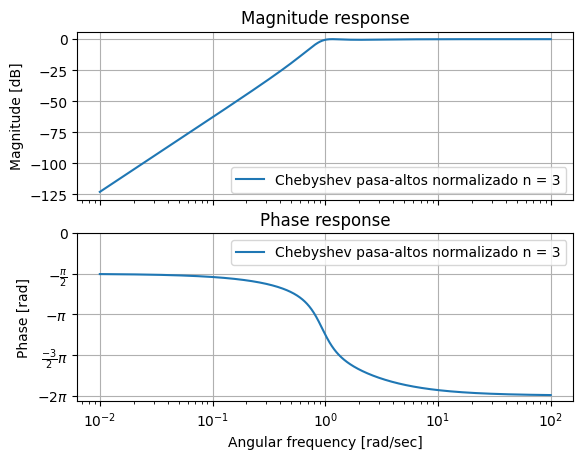

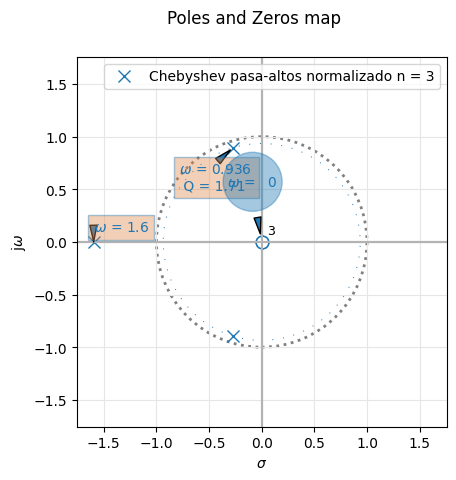

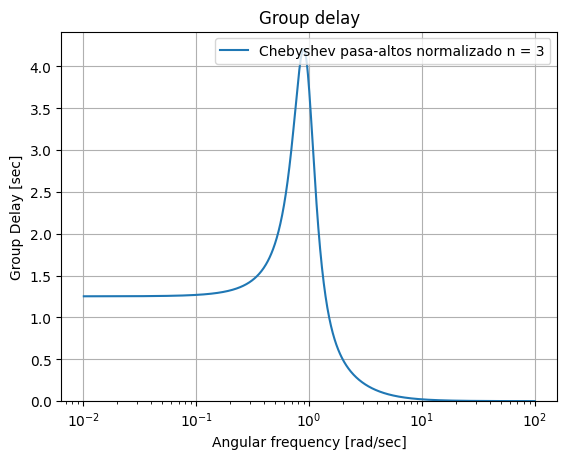

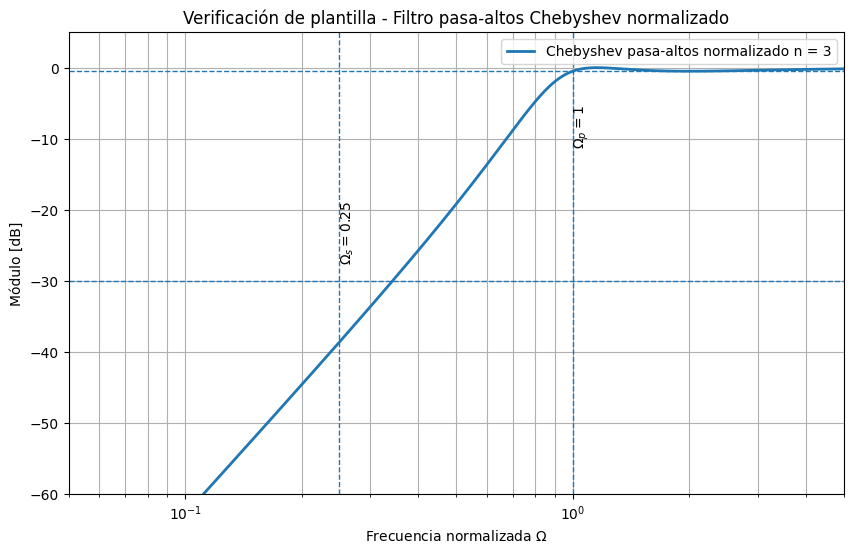

In [12]:
# ============================================================
# Análisis automático con PyTC2
# ============================================================

all_sys = [H_hp_norm]
filter_names = ["Chebyshev pasa-altos normalizado n = 3"]

analyze_sys(all_sys, filter_names)


# ============================================================
# Gráfico manual de verificación de plantilla
# ============================================================

Omega_s_HP = fs/fp   # 0.25
Omega_p_HP = 1       # normalizado

Omega = np.logspace(-2, 1, 2000)

_, mag_db, phase_deg = H_hp_norm.bode(Omega)

plt.figure(figsize=(10, 6))

plt.semilogx(Omega, mag_db, linewidth=2, label="Chebyshev pasa-altos normalizado n = 3")

# Líneas verticales de plantilla
plt.axvline(Omega_s_HP, linestyle="--", linewidth=1)
plt.axvline(Omega_p_HP, linestyle="--", linewidth=1)

# Líneas horizontales de plantilla
plt.axhline(-alpha_min, linestyle="--", linewidth=1)
plt.axhline(-alpha_max, linestyle="--", linewidth=1)

# Textos
plt.text(Omega_s_HP, -alpha_min + 3, r"$\Omega_s = 0.25$", rotation=90)
plt.text(Omega_p_HP, -alpha_max - 10, r"$\Omega_p = 1$", rotation=90)

plt.title("Verificación de plantilla - Filtro pasa-altos Chebyshev normalizado")
plt.xlabel(r"Frecuencia normalizada $\Omega$")
plt.ylabel("Módulo [dB]")

plt.xlim([0.05, 5])
plt.ylim([-60, 5])

plt.grid(True, which="both")
plt.legend()
plt.show()

## Comparación pzmap con el prototipo pasabajos

Polos del pasabajos prototipo:

$$
p_{LP1}=-0.3132+j1.0219
$$

$$
p_{LP2}=-0.6265
$$

$$
p_{LP3}=-0.3132-j1.0219
$$

Al transformar a pasa-altos:

$$
p_{HP}=\frac{1}{p_{LP}}
$$

se obtiene:

$$
p_{HP1}=-0.2742+j0.8945
$$

$$
p_{HP2}=-1.5963
$$

$$
p_{HP3}=-0.2742-j0.8945
$$

El pasa-altos también tiene tres ceros en el origen:

$$
z_1=z_2=z_3=0
$$

Los polos del Chebyshev pasabajos caen sobre la elipse:

$$
\frac{\sigma^2}{\sinh^2(a)}+\frac{\omega^2}{\cosh^2(a)}=1
$$

La transformación a pasa-altos no conserva exactamente esa elipse; genera una curva transformada.

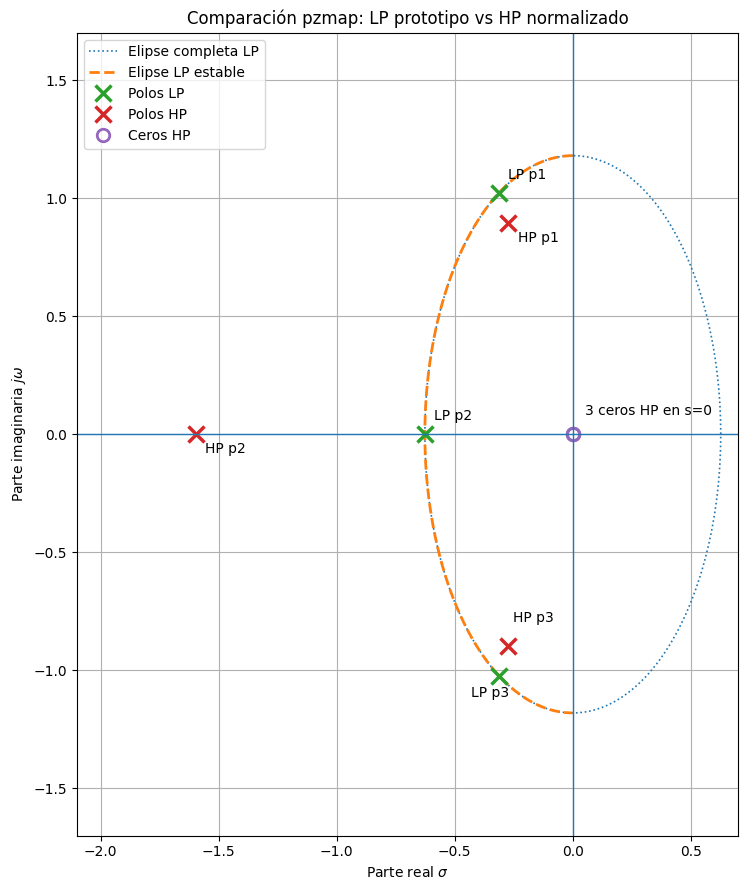

In [13]:
# ============================================================
# Datos del filtro
# ============================================================

alpha_max = 0.5
n = 3

epsilon = np.sqrt(10**(alpha_max/10) - 1)
a = (1/n) * np.arcsinh(1/epsilon)

sigma_e = np.sinh(a)
omega_e = np.cosh(a)

# ============================================================
# Polinomios normalizados
# ============================================================

den_lp_norm = [1, 1.2529, 1.5349, 0.7157]
den_hp_norm = [1, 2.1446, 1.7506, 1.3972]
num_hp_norm = [1, 0, 0, 0]

# ============================================================
# Polos y ceros
# ============================================================

polos_lp = np.roots(den_lp_norm)
polos_hp = np.roots(den_hp_norm)
ceros_hp = np.roots(num_hp_norm)

# Ordeno los polos de arriba hacia abajo
polos_lp = sorted(polos_lp, key=lambda p: np.imag(p), reverse=True)
polos_hp = sorted(polos_hp, key=lambda p: np.imag(p), reverse=True)

# ============================================================
# Elipse de Chebyshev del prototipo pasa-bajos
# ============================================================

theta = np.linspace(0, 2*np.pi, 2000)

x_elipse = -sigma_e * np.sin(theta)
y_elipse = omega_e * np.cos(theta)

# Parte estable de la elipse: semiplano izquierdo
mask_estable = x_elipse <= 0

# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(11, 9))

# Elipse completa LP
plt.plot(
    x_elipse,
    y_elipse,
    linestyle=":",
    linewidth=1.2,
    label="Elipse completa LP"
)

# Elipse LP estable
plt.plot(
    x_elipse[mask_estable],
    y_elipse[mask_estable],
    linestyle="--",
    linewidth=2,
    label="Elipse LP estable"
)

# Polos LP
plt.plot(
    np.real(polos_lp),
    np.imag(polos_lp),
    "x",
    markersize=11,
    markeredgewidth=2.5,
    label="Polos LP"
)

# Polos HP
plt.plot(
    np.real(polos_hp),
    np.imag(polos_hp),
    "x",
    markersize=11,
    markeredgewidth=2.5,
    label="Polos HP"
)

# Ceros HP
plt.plot(
    np.real(ceros_hp),
    np.imag(ceros_hp),
    "o",
    markersize=9,
    fillstyle="none",
    markeredgewidth=2,
    label="Ceros HP"
)

# ============================================================
# Etiquetas de polos LP
# ============================================================

for i, p in enumerate(polos_lp, start=1):

    if i == 1:
        dx = 0.04
        dy = 0.06

    elif i == 2:
        dx = 0.04
        dy = 0.06

    elif i == 3:
        # LP p3: debajo y cerca del polo
        dx = -0.12
        dy = -0.09

    plt.text(
        np.real(p) + dx,
        np.imag(p) + dy,
        f"LP p{i}",
        fontsize=10
    )

# ============================================================
# Etiquetas de polos HP
# ============================================================

for i, p in enumerate(polos_hp, start=1):

    if i == 1:
        dx = 0.04
        dy = -0.08

    elif i == 2:
        dx = 0.04
        dy = -0.08

    elif i == 3:
        # HP p3: arriba y cerca del polo
        dx = 0.02
        dy = 0.10

    plt.text(
        np.real(p) + dx,
        np.imag(p) + dy,
        f"HP p{i}",
        fontsize=10
    )

# Etiqueta de ceros
plt.text(
    0.05,
    0.08,
    "3 ceros HP en s=0",
    fontsize=10
)

# ============================================================
# Ejes y formato
# ============================================================

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title("Comparación pzmap: LP prototipo vs HP normalizado")
plt.xlabel(r"Parte real $\sigma$")
plt.ylabel(r"Parte imaginaria $j\omega$")

plt.grid(True)
plt.legend(loc="upper left")

# Límites más abiertos
plt.xlim(-2.1, 0.7)
plt.ylim(-1.7, 1.7)

# Mantiene escala igual sin warning
ax = plt.gca()
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

---

# 3. Implementación normalizada con estructuras pasivas

La transferencia pasa-altos normalizada es:

$$
H_{HP,norm}(s)=
\frac{s^3}
{s^3+2.1446s^2+1.7506s+1.3972}
$$

Factorizando:

$$
D(s)=(s+1.5963)(s^2+0.5484s+0.8753)
$$

Entonces:

$$
\boxed{
H(s)=
\frac{s}{s+1.5963}
\cdot
\frac{s^2}{s^2+0.5484s+0.8753}
}
$$

## <ins>Sección 1: RC pasa-altos

Un pasa-altos RC cumple:

$$
H_1(s)=\frac{s}{s+\frac{1}{RC}}
$$

Comparando:

$$
\frac{1}{RC}=1.5963
$$

Si se elige $C=1$:

$$
R=\frac{1}{1.5963}=0.6265
$$

$$
\boxed{C=1,\quad R=0.6265}
$$

## <ins>Sección 2: RLC pasa-altos

Para una sección RLC pasa-altos:

$$
H_2(s)=
\frac{s^2}
{s^2+\frac{R}{L}s+\frac{1}{LC}}
$$

Comparando con:

$$
H_2(s)=
\frac{s^2}{s^2+0.5484s+0.8753}
$$

se tiene:

$$
\frac{R}{L}=0.5484
$$

$$
\frac{1}{LC}=0.8753
$$

Si se elige $C=1$:

$$
L=\frac{1}{0.8753}=1.1425
$$

$$
R=0.5484\cdot1.1425=0.6265
$$

$$
\boxed{C=1,\quad R=0.6265,\quad L=1.1425}
$$

## <ins>Circuito

<div align="center">
    <img src="./Imagenes/ChebOrden3.png" alt="Circuito" width="700"/>
</div>

## <ins>Simulación

<div align="center">
    <img src="./Imagenes/ChebModuloFase.png" alt="Modulo y Fase Simulacion LT" width="1700"/>
</div>

Como LTspice grafica la frecuencia en Hz, se debe convertir desde frecuencia angular normalizada:

$$
f_s=\frac{\Omega_s}{2\pi}
$$

$$
f_s=\frac{0.25}{2\pi}=0.0398\ Hz
$$

$$
f_p=\frac{\Omega_p}{2\pi}
$$

$$
f_p=\frac{1}{2\pi}=0.159\ Hz
$$

<div align="center">
    <img src="./Imagenes/modulo.png" alt="Modulo" width="1700"/>
</div>

En la banda de paso se observa el comportamiento ondulatorio característico de una aproximación de Chebyshev tipo I. La respuesta no es plana, como ocurriría en Butterworth, sino que presenta ripple entre aproximadamente \(0\,dB\) y \(-0.5\,dB\).

Para un filtro Chebyshev de orden \(n=3\), la respuesta en módulo presenta tres extremos dentro de la banda de paso. En la simulación se verifica justamente este comportamiento: la curva toca tres veces los límites de ripple de la banda de paso, alternando entre máximos y mínimos.

Esto confirma cualitativamente que la red implementada corresponde a un filtro Chebyshev tipo I de tercer orden.


---

# 4. Reemplazo del inductor mediante GIC de Antoniou

La sección pasiva de segundo orden requiere:

$$
L=1.1425
$$

Una forma de implementar un inductor equivalente con GIC de Antoniou es:

<div align="center">
    <img src="./Imagenes/GICAntoniou.png" alt="GIC de Antoniou" width="300"/>
</div>

$$
L_{eq}=C_2\frac{R_1R_3R_5}{R_4}
$$

Se elige:

$$
C_2=1
$$

$$
R_1=R_3=R_5=1
$$

Entonces:

$$
1.1425=\frac{1}{R_4}
$$

$$
R_4=\frac{1}{1.1425}
$$

$$
R_4=0.8753
$$

Por lo tanto:

$$
\boxed{
C_2=1 ;\quad R_1=R_3=R_5=1 ;\quad R_4=0.8753
}
$$

## <ins>Circuito

<div align="center">
    <img src="./Imagenes/CircuitoGICAntoniou.png" alt="Circuito con GIC Antoniou" width="700"/>
</div>


## <ins>Simulación
<div align="center">
    <img src="./Imagenes/CircuitoGICAntoniou_Modulo_Fase.png" alt="Modulo y Fase Simulacion" width="1700"/>
</div>


---

# 5. Reemplazo de la SOS pasiva por MFB pasa-altos

<div align="center">
    <img src="./Imagenes/MFB_PasaAltos.png" alt="Circuito con GIC Antoniou" width="400"/>
</div>

La SOS a reemplazar es:

$$
H_2(s)=
\frac{s^2}{s^2+0.5484s+0.8753}
$$

## <ins>Transferencia generalizada de la topología

Para la estructura MFB pasa-altos inversora:

$$
\boxed{
H(s)=
-\frac{R_2C_2C_3s^2}
{R_2C_1C_2s^2+(C_1+C_2+C_3)s+\frac{1}{R_1}}
}
$$

Dividiendo por $R_2C_1C_2$:

$$
\boxed{
H(s)=
-\frac{C_3}{C_1}
\frac{s^2}
{s^2+
\frac{C_1+C_2+C_3}{R_2C_1C_2}s+
\frac{1}{R_1R_2C_1C_2}}
}
$$

Comparando con:

$$
H(s)=
-K\frac{s^2}{s^2+\frac{\omega_0}{Q}s+\omega_0^2}
$$

se obtiene:

$$
K=\frac{C_3}{C_1}
$$

$$
\omega_0=
\frac{1}{\sqrt{R_1R_2C_1C_2}}
$$

$$
Q=
\frac{\sqrt{\frac{R_2}{R_1}}\sqrt{C_1C_2}}
{C_1+C_2+C_3}
$$

### <ins>Cálculo de componentes MFB

Se compara:

$$
H_2(s)=
\frac{s^2}{s^2+0.5484s+0.8753}
$$

con:

$$
H(s)=
-K\frac{s^2}{s^2+\frac{\omega_0}{Q}s+\omega_0^2}
$$

Entonces:

$$
\omega_0^2=0.8753
$$

$$
\omega_0=0.9356
$$

$$
\frac{\omega_0}{Q}=0.5484
$$

$$
Q=1.706
$$

Elegimos:

$$
C_1=C_2=C_3=1
$$

Entonces:

$$
K=1
$$

y:

$$
\frac{C_1+C_2+C_3}{R_2C_1C_2}=\frac{3}{R_2}=0.5484
$$

$$
R_2=\frac{3}{0.5484}=5.4705
$$

Además:

$$
\omega_0^2=\frac{1}{R_1R_2}=0.8753
$$

$$
R_1=\frac{1}{0.8753R_2}=0.2089
$$

Por lo tanto:

$$
\boxed{
C_1=C_2=C_3=1,\quad R_1=0.2089,\quad R_2=5.4705
}
$$

La transferencia implementada es:

$$
\boxed{
H_{MFB}(s)=
-\frac{s^2}{s^2+0.5484s+0.8753}
}
$$

El signo negativo de la transferencia aparece porque la configuración MFB pasa-altos es inversora. Para corregir esa inversión de fase, se agrega a la salida un amplificador inversor de ganancia unitaria.

<div align="center">
    <img src="./Imagenes/electronic-analog-oa-inverting.png" alt="Amplificador inversor" width="400"/>
</div>

La ganancia del amplificador inversor es:

$$
A_v=-\frac{R_2}{R_1}
$$

Eligiendo:

$$
R_1=R_2=1
$$

queda:

$$
A_v=-1
$$

Por lo tanto, la transferencia total resulta:

$$
H_{total}(s)=H_{MFB}(s)\cdot(-1)
$$

$$
H_{total}(s)=
\frac{s^2}{s^2+0.5484s+0.8753}
$$

De esta manera se mantiene el módulo de la SOS y se corrige la inversión de fase.

## <ins> Circuito

<div align="center">
    <img src="./Imagenes/MFB_Circuito.png" alt="MFB_Circuito" width="1400"/>
</div>


## <ins> Simulación

<div align="center">
    <img src="./Imagenes/MFB_Modulo_Fase.png" alt="MFB_Modulo_Fase" width="1400"/>
</div>


## Sensibilidades

La definición es:

$$
S_y^x=
\frac{\partial y}{\partial x}\frac{x}{y}
$$

### <ins> Sensibilidad de $\omega_0$ respecto de $C_1$

Como:

$$
\omega_0=(R_1R_2C_1C_2)^{-1/2}
$$

entonces:

$$
\omega_0\propto C_1^{-1/2}
$$

Por lo tanto:

$$
\boxed{
S_{\omega_0}^{C_1}=-\frac{1}{2}
}
$$

### <ins>Sensibilidad de $Q$ respecto de $R_1$

Partimos de:

$$
Q=
\frac{\sqrt{C_1C_2}}{C_1+C_2+C_3}
R_2^{1/2}R_1^{-1/2}
$$

Definimos:

$$
A=\frac{\sqrt{C_1C_2}}{C_1+C_2+C_3}
$$

Entonces:

$$
Q=AR_2^{1/2}R_1^{-1/2}
$$

Derivando:

$$
\frac{\partial Q}{\partial R_1}
=
AR_2^{1/2}
\left(-\frac{1}{2}R_1^{-3/2}\right)
$$

Aplicando sensibilidad:

$$
S_Q^{R_1}=
\frac{\partial Q}{\partial R_1}\frac{R_1}{Q}
$$

$$
S_Q^{R_1}=
-\frac{1}{2}
\frac{AR_2^{1/2}R_1^{-1/2}}{Q}
$$

Como:

$$
Q=AR_2^{1/2}R_1^{-1/2}
$$

queda:

$$
\boxed{
S_Q^{R_1}=-\frac{1}{2}
}
$$

### <ins>Sensibilidad de $Q$ respecto de $R_2$

Partimos de:

$$
Q=AR_2^{1/2}R_1^{-1/2}
$$

Derivando:

$$
\frac{\partial Q}{\partial R_2}
=
AR_1^{-1/2}
\left(\frac{1}{2}R_2^{-1/2}\right)
$$

Aplicando sensibilidad:

$$
S_Q^{R_2}=
\frac{\partial Q}{\partial R_2}\frac{R_2}{Q}
$$

$$
S_Q^{R_2}
=
\frac{1}{2}
\frac{AR_2^{1/2}R_1^{-1/2}}{Q}
$$

Como:

$$
Q=AR_2^{1/2}R_1^{-1/2}
$$

queda:

$$
\boxed{
S_Q^{R_2}=+\frac{1}{2}
}
$$

## <ins>Simulación

In [14]:
# ============================================================
# Definición de variables simbólicas
# ============================================================

R1, R2 = sp.symbols('R1 R2', positive=True)
C1, C2, C3 = sp.symbols('C1 C2 C3', positive=True)

# ============================================================
# Expresiones de la topología MFB pasa-altos
# ============================================================

w0 = 1 / sp.sqrt(R1 * R2 * C1 * C2)

Q = (sp.sqrt(R2 / R1) * sp.sqrt(C1 * C2)) / (C1 + C2 + C3)

# ============================================================
# Función para calcular sensibilidad
# S_y^x = (dy/dx) * (x/y)
# ============================================================

def sensibilidad(y, x):
    return sp.simplify(sp.diff(y, x) * (x / y))

# ============================================================
# Sensibilidades pedidas
# ============================================================

S_w0_C1 = sensibilidad(w0, C1)
S_Q_R1 = sensibilidad(Q, R1)
S_Q_R2 = sensibilidad(Q, R2)

# ============================================================
# Mostrar resultados simbólicos
# ============================================================

print("Sensibilidades simbólicas:")
print()
print("S_w0^C1 =", S_w0_C1)
print("S_Q^R1  =", S_Q_R1)
print("S_Q^R2  =", S_Q_R2)

# ============================================================
# Valores del diseño
# ============================================================

valores = {
    C1: 1,
    C2: 1,
    C3: 1,
    R1: 0.2089,
    R2: 5.4705
}

# ============================================================
# Evaluación numérica
# ============================================================

w0_num = w0.subs(valores)
Q_num = Q.subs(valores)

S_w0_C1_num = S_w0_C1.subs(valores)
S_Q_R1_num = S_Q_R1.subs(valores)
S_Q_R2_num = S_Q_R2.subs(valores)

print()
print("Valores del diseño:")
print()
print(f"w0 = {float(w0_num):.4f}")
print(f"Q  = {float(Q_num):.4f}")

print()
print("Sensibilidades numéricas:")
print()
print(f"S_w0^C1 = {float(S_w0_C1_num):.4f}")
print(f"S_Q^R1  = {float(S_Q_R1_num):.4f}")
print(f"S_Q^R2  = {float(S_Q_R2_num):.4f}")

Sensibilidades simbólicas:

S_w0^C1 = -1/2
S_Q^R1  = -1/2
S_Q^R2  = 1/2

Valores del diseño:

w0 = 0.9354
Q  = 1.7058

Sensibilidades numéricas:

S_w0^C1 = -0.5000
S_Q^R1  = -0.5000
S_Q^R2  = 0.5000



---

# Bonus 1. ¿Se puede implementar una red del mismo orden con máxima planicidad?

La aproximación de máxima planicidad corresponde a **Butterworth**.

En este caso se quiere analizar si es posible cumplir los mismos requerimientos usando una red del **mismo orden** que el filtro Chebyshev obtenido previamente.

Para el filtro Chebyshev se obtuvo:

$$
n=3
$$

Ahora verificamos si un Butterworth de orden 3 cumple la plantilla.

### <ins>Datos de la plantilla

$$
\alpha_{max}=0.5\,dB
$$

$$
\alpha_{min}=30\,dB
$$

$$
f_p=40\,kHz
$$

$$
f_s=10\,kHz
$$

Como el filtro es pasa-altos, se transforma al prototipo pasa-bajos mediante:

$$
\Omega_s=\frac{f_p}{f_s}
$$

Entonces:

$$
\Omega_s=\frac{40\,kHz}{10\,kHz}
$$

$$
\Omega_s=4
$$


### <ins>Cálculo de $\varepsilon^2$

Para Butterworth, usando la atenuación máxima en banda de paso:

$$
\varepsilon^2=10^{\frac{\alpha_{max}}{10}}-1
$$

Reemplazando:

$$
\varepsilon^2=10^{\frac{0.5}{10}}-1
$$

$$
\varepsilon^2=10^{0.05}-1
$$

$$
\varepsilon^2=0.1220
$$


### <ins>Verificación iterativa del orden

La atenuación en la frecuencia de rechazo para Butterworth es:

$$
\alpha(n)=10\log_{10}\left(1+\varepsilon^2\Omega_s^{2n}\right)
$$

Con:

$$
\varepsilon^2=0.1220
$$

$$
\Omega_s=4
$$

se evalúa iterativamente para distintos valores de $n$.



### <ins>Tabla de verificación

| Orden $n$ | Atenuación $\alpha(n)$ [dB] | ¿Cumple $\alpha_{min}=30\,dB$? |
|---:|---:|:---:|
| 1 | 4.70 | No |
| 2 | 15.08 | No |
| 3 | 27.00 | No |
| 4 | 39.03 | Sí |

A partir de la verificación iterativa, se observa que:

$$
n=3 \Rightarrow \alpha_s\approx27\,dB
$$

Como se requiere:

$$
\alpha_{min}=30\,dB
$$

entonces:

$$
\boxed{\text{No se puede cumplir la plantilla con máxima planicidad usando el mismo orden }n=3.}
$$

El menor orden Butterworth que cumple la plantilla es:

$$
\boxed{n=4}
$$

## <ins> Simulación

Verificación en los puntos de diseño
------------------------------------
Chebyshev n=3:
  En Ωs = 0.25: -38.61 dB
  En Ωp = 1: -0.50 dB

Butterworth n=3:
  En Ωs = 0.25: -27.00 dB
  En Ωp = 1: -0.50 dB

Butterworth n=4:
  En Ωs = 0.25: -39.03 dB
  En Ωp = 1: -0.50 dB



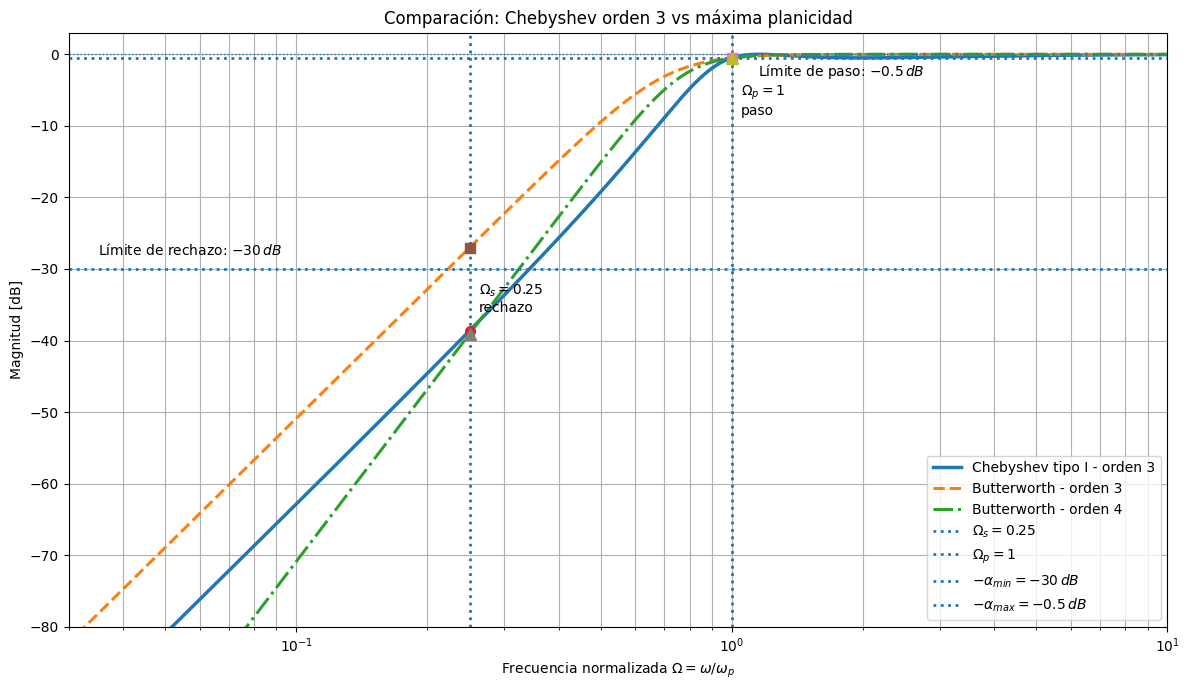

In [6]:
# ============================================================
# Datos de la plantilla
# ============================================================

alpha_max = 0.5   # dB
alpha_min = 30    # dB

Omega_p = 1
Omega_s = 0.25    # fs/fp = 10kHz/40kHz

# Vector de frecuencia normalizada
Omega = np.logspace(-2, 1.2, 3000)

# ============================================================
# 1) Chebyshev tipo I de orden 3
# ============================================================
# Para Chebyshev I pasa-altos, Wn = Omega_p = 1
# En Omega_p la atenuación es alpha_max = 0.5 dB

n_cheby = 3

num_ch, den_ch = signal.cheby1(
    N=n_cheby,
    rp=alpha_max,
    Wn=Omega_p,
    btype='highpass',
    analog=True,
    output='ba'
)

_, H_ch = signal.freqs(num_ch, den_ch, Omega)
mag_ch_db = 20*np.log10(np.abs(H_ch))

# ============================================================
# 2) Butterworth de orden 3
# ============================================================
# Se ajusta Omega_0 para que en Omega_p = 1 tenga alpha_max = 0.5 dB

n_butt3 = 3

Omega0_butt3 = (10**(alpha_max/10) - 1)**(1/(2*n_butt3)) * Omega_p

num_b3, den_b3 = signal.butter(
    N=n_butt3,
    Wn=Omega0_butt3,
    btype='highpass',
    analog=True,
    output='ba'
)

_, H_b3 = signal.freqs(num_b3, den_b3, Omega)
mag_b3_db = 20*np.log10(np.abs(H_b3))

# ============================================================
# 3) Butterworth de orden 4
# ============================================================
# También se ajusta para que en Omega_p = 1 tenga alpha_max = 0.5 dB

n_butt4 = 4

Omega0_butt4 = (10**(alpha_max/10) - 1)**(1/(2*n_butt4)) * Omega_p

num_b4, den_b4 = signal.butter(
    N=n_butt4,
    Wn=Omega0_butt4,
    btype='highpass',
    analog=True,
    output='ba'
)

_, H_b4 = signal.freqs(num_b4, den_b4, Omega)
mag_b4_db = 20*np.log10(np.abs(H_b4))

# ============================================================
# Verificación en puntos de interés
# ============================================================

def evaluar_en_punto(num, den, Omega_eval):
    _, H = signal.freqs(num, den, [Omega_eval])
    mag_db = 20*np.log10(abs(H[0]))
    return mag_db

ch_Os = evaluar_en_punto(num_ch, den_ch, Omega_s)
ch_Op = evaluar_en_punto(num_ch, den_ch, Omega_p)

b3_Os = evaluar_en_punto(num_b3, den_b3, Omega_s)
b3_Op = evaluar_en_punto(num_b3, den_b3, Omega_p)

b4_Os = evaluar_en_punto(num_b4, den_b4, Omega_s)
b4_Op = evaluar_en_punto(num_b4, den_b4, Omega_p)

print("Verificación en los puntos de diseño")
print("------------------------------------")
print(f"Chebyshev n=3:")
print(f"  En Ωs = {Omega_s}: {ch_Os:.2f} dB")
print(f"  En Ωp = {Omega_p}: {ch_Op:.2f} dB")
print()

print(f"Butterworth n=3:")
print(f"  En Ωs = {Omega_s}: {b3_Os:.2f} dB")
print(f"  En Ωp = {Omega_p}: {b3_Op:.2f} dB")
print()

print(f"Butterworth n=4:")
print(f"  En Ωs = {Omega_s}: {b4_Os:.2f} dB")
print(f"  En Ωp = {Omega_p}: {b4_Op:.2f} dB")
print()

# ============================================================
# Gráfico comparativo
# ============================================================

plt.figure(figsize=(12, 7))

plt.semilogx(Omega, mag_ch_db, linewidth=2.5, label="Chebyshev tipo I - orden 3")
plt.semilogx(Omega, mag_b3_db, linewidth=2.2, linestyle="--", label="Butterworth - orden 3")
plt.semilogx(Omega, mag_b4_db, linewidth=2.2, linestyle="-.", label="Butterworth - orden 4")

# Líneas verticales de diseño
plt.axvline(Omega_s, linestyle=":", linewidth=2, label=r"$\Omega_s=0.25$")
plt.axvline(Omega_p, linestyle=":", linewidth=2, label=r"$\Omega_p=1$")

# Líneas horizontales de diseño
plt.axhline(-alpha_min, linestyle=":", linewidth=2, label=r"$-\alpha_{min}=-30\,dB$")
plt.axhline(-alpha_max, linestyle=":", linewidth=2, label=r"$-\alpha_{max}=-0.5\,dB$")
plt.axhline(0, linestyle=":", linewidth=1)

# Marcadores en los puntos de interés
plt.plot(Omega_s, ch_Os, "o", markersize=7)
plt.plot(Omega_p, ch_Op, "o", markersize=7)

plt.plot(Omega_s, b3_Os, "s", markersize=7)
plt.plot(Omega_p, b3_Op, "s", markersize=7)

plt.plot(Omega_s, b4_Os, "^", markersize=8)
plt.plot(Omega_p, b4_Op, "^", markersize=8)

# Anotaciones
plt.text(
    Omega_s*1.05,
    -alpha_min - 6,
    r"$\Omega_s=0.25$" + "\n" + "rechazo",
    fontsize=10
)

plt.text(
    Omega_p*1.05,
    -alpha_max - 8,
    r"$\Omega_p=1$" + "\n" + "paso",
    fontsize=10
)

plt.text(
    0.035,
    -alpha_min + 2,
    r"Límite de rechazo: $-30\,dB$",
    fontsize=10
)

plt.text(
    1.15,
    -alpha_max - 2.5,
    r"Límite de paso: $-0.5\,dB$",
    fontsize=10
)

plt.title("Comparación: Chebyshev orden 3 vs máxima planicidad")
plt.xlabel(r"Frecuencia normalizada $\Omega=\omega/\omega_p$")
plt.ylabel("Magnitud [dB]")

plt.grid(True, which="both")
plt.legend(loc="lower right")

plt.xlim(0.03, 10)
plt.ylim(-80, 3)

plt.tight_layout()
plt.show()

## <ins>Conclusión

A partir de la comparación entre la aproximación de Chebyshev tipo I y la aproximación de máxima planicidad Butterworth, se observa que, para un mismo orden \(n=3\), el filtro Chebyshev presenta una transición más rápida entre la banda de rechazo y la banda de paso.

Esto permite que la aproximación de Chebyshev cumpla con la atenuación mínima requerida en la frecuencia de rechazo:$\alpha_{min}=30\,dB$ manteniendo el mismo orden del filtro.

En cambio, la aproximación Butterworth de orden \(n=3\) no alcanza dicha atenuación en la frecuencia de rechazo. Esto ocurre porque Butterworth prioriza una respuesta completamente plana en la banda de paso, pero como consecuencia su transición es más lenta. Por este motivo, para cumplir la misma plantilla con máxima planicidad es necesario aumentar el orden a:

$$
n=4
$$

La ventaja de Chebyshev es entonces su mayor selectividad para un mismo orden. Sin embargo, esta mejora se obtiene a costa de introducir una oscilación en la banda de paso, conocida como ripple. En este caso, dicha oscilación está limitada por:

$$
\alpha_{max}=0.5\,dB
$$

Por lo tanto, se concluye que la aproximación de Chebyshev permite cumplir los requerimientos con menor orden que Butterworth, pero sacrificando la planicidad de la banda de paso.

# <ins> Resolución manuscrita:

## <ins>TS3.pdf:

In [15]:
from IPython.display import IFrame
IFrame("Imagenes/TS3.pdf", width=1000, height=700)